## "Optogenetics" 
 ### Test transfer of the networks with "optogenetics". When testing an untrained angle, fix the active neurons to be the same as those active before learning.
 
Created Sept 27. This notebook also includes a cell that tests transfer across $\sigma_s$.

There are two potential schemes. In the "fixed readout" scheme, the readout is the same as one optimized for the without-opto network. In the "flexible readout" scheme, the readout is retrained for the opto-ed network.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch, pickle, utils, model, copy
from tqdm import trange, tqdm


%load_ext autoreload
%autoreload 2

torch.set_grad_enabled(False)


# The sig_w values to test
standard_stim = utils.GaborStimuli(args, simple_mode=True)

calc_MLD(): MLD error is 0.15865647220940177


## Compare specificity index with or without "optogenetics", flexible readout scheme
In this scheme, a new readout is trained after optogenetics has been applied.

In [38]:
theory_dict_names = ['theory_3L_sigs0p2', 'theory_3L_sigs0p4', 'theory_3L_sigs0p6', 'theory_3L_sigs1p2', 'theory_3L_sigs1p4']
theory_dicts = [pickle.load(open('Saved Results/' + _name, 'rb')) for _name in theory_dict_names]
dict_ind = 0

args.sig_s = 0.2
sig_w_ind = 23

probe_angles = np.linspace(np.pi, 2*np.pi, 200)
sig_w_array = theory_dicts[dict_ind]['vary_values']

J0 = np.zeros(len(probe_angles))
J = np.zeros_like(J0)
J_opto = np.zeros_like(J0)


standard_stim = utils.GaborStimuli(args, simple_mode=True, verbose=False)



probe_args = copy.copy(args); probe_args.sig_w = sig_w_array[sig_w_ind]

# create a pair of networks
bl_net = model.Model(probe_args)
trained_net = model.Model(probe_args)

utils.load_theory_from_file(trained_net, theory_dicts[dict_ind], sig_w_ind)
J0 = utils.get_mean_field_fi(bl_net, standard_stim)
x1_overlaps = np.zeros_like(probe_angles)
x1_delv_overlaps = np.zeros_like(probe_angles)

w_effs0 = utils.get_effective_weights(bl_net, standard_stim.x0, full_mat=True)[0]
F0 = w_effs0[2] @ w_effs0[1] @ w_effs0[0]
a0 = utils.mse_optimal_a(F0, standard_stim)
v0 = F0.T @ a0
delv = standard_stim.x1_normed.numpy().flatten() - v0.flatten()

for i in trange(len(probe_angles)):
    probe_args.theta = probe_angles[i]
    probe_stim = utils.GaborStimuli(probe_args, verbose=False, simple_mode=True)
    x1_overlaps[i] = utils.cos(standard_stim.x1, probe_stim.x1)
    x1_delv_overlaps[i] = utils.cos(delv, probe_stim.x1)
    

    bl_active_inds = utils.get_effective_weights(bl_net, probe_stim.x0)[1]
    
    

    # first, get the un-manipulated readout
    w_effs = utils.get_effective_weights(trained_net, probe_stim.x0, full_mat=True)[0]

    # manipulated forward mat
    manipulated_Ws = []
    for j in range(3):
        mask = np.zeros_like(trained_net.Ws[j])
        mask[bl_active_inds[j+1]] = 1
        manipulated_Ws.append(trained_net.Ws[j] * mask)

    J_opto[i] = utils.J_from_effective_weights(manipulated_Ws, probe_args.noise_var, probe_stim.x1.numpy())

    J[i] = utils.J_from_effective_weights(w_effs, probe_args.noise_var, probe_stim.x1.numpy())




  6%|▌         | 12/200 [00:05<01:21,  2.30it/s]


KeyboardInterrupt: 

## Signal and noise magnitude, with or without optogenetics

Always computes signal and noise in the last layer.

In [1]:
theory_dict_names = ['theory_3L_sigs0p2', 'theory_3L_sigs0p4', 'theory_3L_sigs0p6', 'theory_3L_sigs1p2', 'theory_3L_sigs1p4']
theory_dicts = [pickle.load(open('Saved Results/' + _name, 'rb')) for _name in theory_dict_names]
dict_ind = 3

args = theory_dicts[dict_ind]['args']
sig_w_ind = 0
args.sig_w = theory_dicts[dict_ind]['vary_values'][sig_w_ind]

bl_net = model.Model(args)
trained_net = model.Model(args)
utils.load_theory_from_file(trained_net, theory_dicts[dict_ind], sig_w_ind)

probe_angles = np.linspace(np.pi, 2*np.pi, 200)
sig_w_array = theory_dicts[dict_ind]['vary_values']

signal_mag = np.zeros_like(probe_angles)
signal_opto_mag = np.zeros_like(probe_angles)
bl_signal_mag = np.zeros_like(probe_angles)

inv_noise_mag = np.zeros_like(probe_angles)
inv_noise_opto_mag = np.zeros_like(probe_angles)
inv_bl_noise_mag = np.zeros_like(probe_angles)

for i in trange(len(probe_angles)):
    args.theta = probe_angles[i]
    probe_stim = utils.GaborStimuli(args, verbose=False, simple_mode=True)
    

    bl_active_inds = utils.get_effective_weights(bl_net, probe_stim.x0)[1]
    

    # first, get the un-manipulated readout
    w_effs = utils.get_effective_weights(trained_net, probe_stim.x0, full_mat=False)[0]
    w_effs_bl = utils.get_effective_weights(bl_net, probe_stim.x0, full_mat=False)[0]

    # manipulated forward mat
    manipulated_Ws = []
    for j in range(3):
        mask = np.zeros_like(trained_net.Ws[j])
        mask[bl_active_inds[j+1]] = 1
        manipulated_Ws.append(trained_net.Ws[j] * mask)

    F_opto = utils.matrix_prod(manipulated_Ws)
    F = utils.matrix_prod(w_effs)
    F0 = utils.matrix_prod(w_effs_bl)

    # computes signal magnitude
    signal_opto_mag[i] = np.linalg.norm(F_opto @ probe_stim.x1.t().numpy())
    signal_mag[i] = np.linalg.norm(F @ probe_stim.x1.t().numpy())
    bl_signal_mag[i] = np.linalg.norm(F0 @ probe_stim.x1.t().numpy())


    # compute noise magnitude (inverse of noise, projected on the signal)
    sig_dir = F_opto @ probe_stim.x1.numpy().T; sig_dir /= np.linalg.norm(sig_dir)
    inv_noise_opto_mag[i] = float(sig_dir.T @ np.linalg.inv(F_opto @ F_opto.T + np.eye(F_opto.shape[0]) * 1e-6) @ sig_dir)

    sig_dir = F @ probe_stim.x1.numpy().T; sig_dir /= np.linalg.norm(sig_dir)
    inv_noise_mag[i] = float(sig_dir.T @ np.linalg.inv(F @ F.T + np.eye(F.shape[0]) * 1e-6) @ sig_dir)

    sig_dir = F0 @ probe_stim.x1.numpy().T; sig_dir /= np.linalg.norm(sig_dir)
    inv_bl_noise_mag[i] = float(sig_dir.T @ np.linalg.inv(F0 @ F0.T + np.eye(F0.shape[0]) * 1e-6) @ sig_dir)


NameError: name 'pickle' is not defined

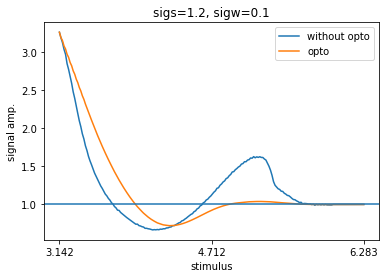

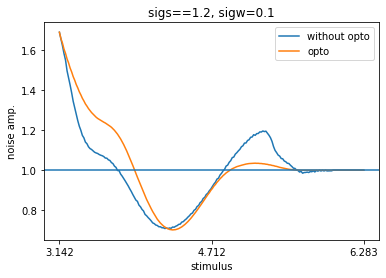

In [12]:
plt.figure()
plt.plot(probe_angles, signal_mag**2 / bl_signal_mag**2, label='without opto')
plt.plot(probe_angles, signal_opto_mag**2 / bl_signal_mag**2, label='opto')
plt.xlabel('stimulus')
plt.ylabel('signal amp.')
plt.axhline(1)
plt.xticks([np.pi, np.pi*1.5, np.pi*2])
plt.legend()
plt.title(f'sigs={args.sig_s}, sigw={args.sig_w}')
plt.savefig('figures/raw/signal_mag_opto.svg')

plt.figure()
plt.plot(probe_angles, 1 / inv_noise_mag * inv_bl_noise_mag, label='without opto')
plt.plot(probe_angles, 1 / inv_noise_opto_mag * inv_bl_noise_mag, label='opto')
plt.xlabel('stimulus')
plt.ylabel('noise amp.')
plt.axhline(1)
plt.xticks([np.pi, np.pi*1.5, np.pi*2])
plt.legend()
plt.title(f'sigs=={args.sig_s}, sigw={args.sig_w}')
plt.savefig('figures/raw/noise_mag_opto.svg')

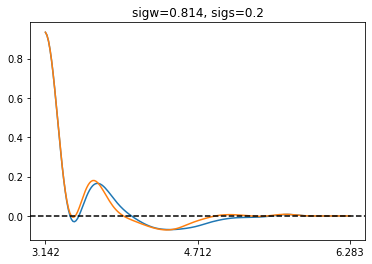

In [20]:
from scipy.ndimage import gaussian_filter1d
smooth_size = 3

plt.figure()
plt.plot(probe_angles, gaussian_filter1d(utils.normalize_j(J, J0), smooth_size))
plt.plot(probe_angles, gaussian_filter1d(utils.normalize_j(J_opto, J0), smooth_size))
plt.xticks([np.pi, np.pi*1.5, np.pi*2])
plt.axhline(0, color='k', ls='--')
plt.title(f'sigw={sig_w_array[sig_w_ind]:.3f}, sigs={args.sig_s}')
plt.savefig('figures/raw/opto_sigs0p2_sigw0p8.svg')

# plt.figure()
# plt.plot(probe_angles, np.abs(x1_overlaps))
# plt.title('x1-x1 overlap')

# plt.figure()
# plt.plot(probe_angles, np.abs(x1_delv_overlaps))
# plt.title('x1-delv overlap')


## Compare specificity index with or without "optogenetics", fixed readout scheme

In [2]:
theory_dict_names = ['theory_3L_sigs0p2', 'theory_3L_sigs0p4', 'theory_3L_sigs0p6']
theory_dicts = [pickle.load(open('Saved Results/' + _name, 'rb')) for _name in theory_dict_names]
dict_ind = 0

args.sig_s = 0.2

probe_angles = np.linspace(np.pi, 2*np.pi, 64)

J0 = np.zeros((30, len(probe_angles)))
J = np.zeros_like(J0)
J_opto = np.zeros_like(J0)

standard_stim = train_utils.GaborStimuli(args, simple_mode=True, verbose=False)

for sig_w_ind in trange(30):
    probe_args = copy.copy(args); probe_args.sig_w = sig_w_array[sig_w_ind]

    # create a pair of networks
    bl_net = model.Model(probe_args)
    trained_net = model.Model(probe_args)

    t_utils.load_theory_from_file(trained_net, theory_dicts[dict_ind], sig_w_ind)
    J0[sig_w_ind] = r_utils.get_mean_field_fi(bl_net, standard_stim)

    for i in range(len(probe_angles)):
        probe_args.theta = probe_angles[i]
        probe_stim = train_utils.GaborStimuli(probe_args, verbose=False, simple_mode=True)
        
        bl_active_inds = r_utils.get_effective_weights(bl_net, probe_stim.x0)[1]

        # first, get the un-manipulated readout
        w_effs = r_utils.get_effective_weights(trained_net, probe_stim.x0, full_mat=True)[0]
        F = w_effs[2] @ w_effs[1] @ w_effs[0]
        covar = F @ F.T * probe_args.noise_var
        _u, _s, _v = np.linalg.svd(covar)
        readout = np.linalg.inv(covar + _s[0] * 1e-6 * np.eye(F.shape[0])) @\
        F @ probe_stim.x1.t().numpy()

        # manipulated forward mat
        manipulated_Ws = []
        for j in range(3):
            mask = np.zeros_like(trained_net.Ws[j])
            mask[bl_active_inds[j+1]] = 1
            manipulated_Ws.append(trained_net.Ws[j] * mask)

        F_opto = manipulated_Ws[2] @ manipulated_Ws[1] @ manipulated_Ws[0]

        signal_opto = float(readout.T @ F_opto @ probe_stim.x1.t().numpy()) **2
        noise_opto = np.linalg.norm(F_opto.T @ readout)**2 * probe_args.noise_var
        J_opto[sig_w_ind, i] = signal_opto / noise_opto

        J[sig_w_ind, i] = float(readout.T @ F @ probe_stim.x1.t().numpy())



23%|██▎       | 7/30 [01:28<04:52, 12.71s/it]


KeyboardInterrupt: 

### Convert transfer to specificity indices

Text(0.5, 1.0, 'sigma_s=0.4')

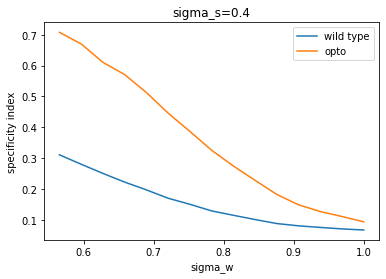

In [94]:
SI = np.zeros(30)
optoSI = np.zeros(30)

for i in range(30):
    normalized_del_fi = (J_opto[i] - J0[i]) / (J_opto[i] - J0[i]).max()
    optoSI[i] = np.abs(normalized_del_fi).T @ (probe_angles - np.pi) / 64 * np.pi

    normalized_del_fi = (J[i] - J0[i]) / (J[i] - J0[i]).max()
    SI[i] = np.abs(normalized_del_fi).T @ (probe_angles - np.pi) / 64 * np.pi
    
plt.figure()
plt.plot(sig_w_array[15:], SI[15:], label='wild type')
plt.plot(sig_w_array[15:], optoSI[15:], label='opto'); plt.xlabel('sigma_w'); plt.ylabel('specificity index'); plt.legend()
plt.title('sigma_s=0.4')
# plt.savefig('figures/raw/SI_opto_sigs0P2.svg')

Text(0.5, 1.0, 'sigma_s=0.2')

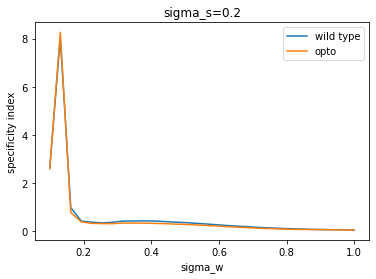

In [8]:
SI = np.zeros(len(sig_w_array))
optoSI = np.zeros(len(sig_w_array))

for i in range(len(sig_w_array)):
    normalized_del_fi = (J_opto[i] - J0[i]) / (J_opto[i] - J0[i]).max()
    optoSI[i] = np.abs(normalized_del_fi).T @ (probe_angles - np.pi) / len(probe_angles) * np.pi

    normalized_del_fi = (J[i] - J0[i]) / (J[i] - J0[i]).max()
    SI[i] = np.abs(normalized_del_fi).T @ (probe_angles - np.pi) / len(probe_angles) * np.pi
    
plt.figure()
plt.plot(sig_w_array, SI, label='wild type')
plt.plot(sig_w_array, optoSI, label='opto'); plt.xlabel('sigma_w'); plt.ylabel('specificity index'); plt.legend()
plt.title(f'sigma_s={args.sig_s}')
# plt.savefig('figures/raw/SI_opto_sigs0P2_flexible_readout.svg')

### Save results

In [118]:
to_save = {'args':args, 'sig_w':sig_w_array, 'J':J, 'J0':J0, 'J_opto_flexible':J_opto}
pickle.dump(to_save, open('Plot Data/sigs1P2_flexible_ro_opto_transfer', 'wb'))

## Transfer across $\sigma_s$

Transfer results is compared with two auxillary figures. The first one is the overlap of trained $x_1$ with other $x_1$. The second one is $\Delta v$ with the other $x_1$.

*There is no point doing "optogenetics" here because the active neurons for each $\sigma_s$ does not change after learning*.

In [11]:
theory_dict_names = ['theory_1L_sigs1P2', 'theory_3L_sigs0p2', 'theory_3L_sigs0p4', 'theory_3L_sigs0p6', 'theory_3L_sigs1p0', 'theory_3L_sigs1p2', 'theory_3L_sigs1p4']
theory_dicts = [pickle.load(open('Saved Results/' + _name, 'rb')) for _name in theory_dict_names]
    
def make_sigma_s_transfer(dict_ind, sig_w_ind, theta, trained_sigs, sig_s_array):

    probe_args = copy.copy(args)
    probe_args.n_layers = 1
    probe_args.theta = theta
    probe_args.sig_w = theory_dicts[dict_ind]['sig_w'][sig_w_ind]

    # create an instance of the trained stimulus
    probe_args.sig_s = trained_sigs
    trained_stim = train_utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)


    # create a pair of networks, one untrained, one trained
    bl_net = model.Model(probe_args)
    trained_net = model.Model(probe_args); t_utils.load_theory_from_file(trained_net, theory_dicts[dict_ind], sig_w_ind)


    # calculate the DelV for the trained stimulus
    w_effs0 = r_utils.get_effective_weights(bl_net, trained_stim.x0, full_mat=True)[0]
#     forward_mat = w_effs0[2] @ w_effs0[1] @ w_effs0[0]
    forward_mat = w_effs0[0]
    a = train_utils.mse_optimal_a(forward_mat, trained_stim)
    v0 = forward_mat.T @ a
    delv = trained_stim.x1_normed.numpy().T - v0
#     delv -= delv.T @ trained_stim.x1_normed.numpy().T * trained_stim.x1_normed.numpy().T

    # create some arrays to store stuff
    x1_overlaps = np.zeros_like(sig_s_array)
    x1_overlaps_with_delv = np.zeros_like(sig_s_array)

    J0 = np.zeros_like(sig_s_array)
    J = np.zeros_like(J0)
    J_opto = np.zeros_like(J0)

    for i in trange(len(sig_s_array)):
        probe_args.sig_s = sig_s_array[i]
        probe_stim = train_utils.GaborStimuli(probe_args, verbose=False, simple_mode=True)

        x1_overlaps[i] = utils.cos(trained_stim.x1.numpy(), probe_stim.x1.numpy())
#         bl_active_inds = r_utils.get_effective_weights(bl_net, probe_stim.x0)[1]
        J0[i] = r_utils.get_mean_field_fi(bl_net, probe_stim)

        # first, get the un-manipulated readout
        w_effs = r_utils.get_effective_weights(trained_net, probe_stim.x0, full_mat=True)[0]
        x1_overlaps_with_delv[i] = utils.cos(delv, probe_stim.x1.numpy())

        J[i] = t_utils.J_from_F(w_effs, probe_args.noise_var, probe_stim.x1.numpy())
    return J0, J, x1_overlaps, x1_overlaps_with_delv

sig_s_array = np.linspace(0.1, 1.5, 60)
sig_w_ind = 0
J0, J, x1_overlaps, x1_overlaps_with_delv = make_sigma_s_transfer(dict_ind=0, sig_w_ind=sig_w_ind,
theta=np.pi, trained_sigs=1.2, sig_s_array=sig_s_array)
# J0_2, J_2, x1_overlaps_2, x1_overlaps_with_delv_2 = make_sigma_s_transfer(dict_ind=4, sig_w_ind=sig_w_ind,
# theta=np.pi, trained_sigs=1.2, sig_s_array=sig_s_array)

# sig_s_array = np.linspace(0.1, 1.2, 60)
# sig_w_ind = 23
# J0, J, x1_overlaps, x1_overlaps_with_delv = make_sigma_s_transfer(dict_ind=0, sig_w_ind=sig_w_ind,
#                                                                   theta=np.pi, trained_sigs=0.2, sig_s_array=sig_s_array)
# J0_2, J_2, x1_overlaps_2, x1_overlaps_with_delv_2 = make_sigma_s_transfer(dict_ind=1, sig_w_ind=sig_w_ind,
#                                                                           theta=np.pi, trained_sigs=0.4, sig_s_array=sig_s_array)

100%|██████████| 60/60 [00:11<00:00,  5.04it/s]


Text(0.5, 0, 'sigs')

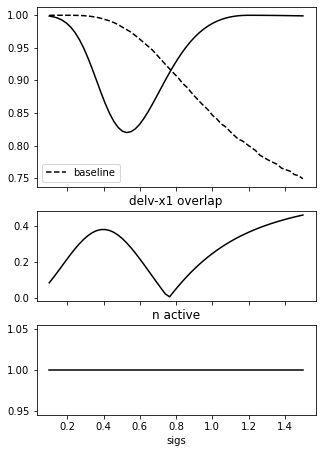

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True,
                               gridspec_kw={'height_ratios': [2, 1, 1]},
                               figsize=(5, 7.5))

plt.sca(axes[0])
plt.plot(sig_s_array, J, color='k')
# plt.plot(sig_s_array, J_2, color='r')
plt.plot(sig_s_array, J0, label='baseline', color='k', ls='--')
# plt.plot(sig_s_array, J0_2, label='baseline', color='r', ls='--')
plt.legend()
# plt.title(f'sigw={sig_w_array[sig_w_ind]:.3f}')

plt.sca(axes[1])
plt.plot(sig_s_array, np.abs(x1_overlaps_with_delv), color='k')
# plt.plot(sig_s_array, np.abs(x1_overlaps_with_delv_2), color='r')
plt.title('delv-x1 overlap')

plt.sca(axes[2])
plt.plot(sig_s_array, (np.ones_like(sig_s_array)), color='k')
# plt.plot(sig_s_array, (np.ones_like(sig_s_array)), color='r')
# plt.axhline(0)
plt.title('n active')
plt.xlabel('sigs')
# plt.savefig('figures/raw/transfer_over_sigs_sigw0p1_sigs1p2_1p4.svg')

In [7]:
x1_overlaps_with_delv

array([ 0.08529513,  0.0856609 ,  0.07761451,  0.06181547,  0.03931841,
        0.0113167 , -0.02102129, -0.05663935, -0.09462775, -0.13422617,
       -0.17481048, -0.21587323, -0.25700337, -0.29786777, -0.33819535,
       -0.37776488, -0.41639453, -0.45393476, -0.49026224, -0.52527559,
       -0.55889273, -0.59104818, -0.62169176, -0.65078735, -0.6783123 ,
       -0.70425689, -0.72862291, -0.75142395, -0.7726841 , -0.79243714,
       -0.81072551, -0.82759917, -0.84311473, -0.8573333 , -0.87032038,
       -0.88214391, -0.89287335, -0.90257889, -0.91133004, -0.91919506,
       -0.92624056, -0.9325304 , -0.93812633, -0.94308597, -0.94746453,
       -0.95131356, -0.95468092, -0.95761132, -0.96014577, -0.96232265,
       -0.96417695, -0.9657405 , -0.96704298, -0.96811068, -0.96896839,
       -0.96963775, -0.97013921, -0.97049069, -0.97070855, -0.97080791])

In [119]:
J0, J, x1_overlaps, x1_overlaps_with_delv = make_sigma_s_transfer(dict_ind=0, sig_w_ind=23, theta=np.pi, trained_sigs=0.2)
J0_sigw0p5, J_sigw0p5, x1_overlaps_sigw0p5, x1_overlaps_with_delv_sigw0p5 = make_sigma_s_transfer(dict_ind=0, sig_w_ind=13, theta=np.pi, trained_sigs=0.2)


100%|██████████| 60/60 [00:12<00:00,  4.97it/s]


Text(0.5, 1.0, 'x1-x1 overlap')

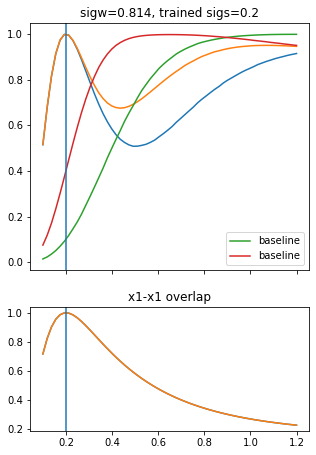

In [121]:

fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]},
                               figsize=(5, 7.5))

plt.sca(axes[0])
plt.plot(sig_s_array, J)
plt.plot(sig_s_array, J_sigw0p5)
plt.plot(sig_s_array, J0, label='baseline')
plt.plot(sig_s_array, J0_sigw0p5, label='baseline')
plt.legend()
plt.title(f'sigw={sig_w_array[sig_w_ind]:.3f}, trained sigs={trained_sigs}')
plt.axvline(0.2)

plt.sca(axes[1])
plt.plot(sig_s_array, x1_overlaps)
plt.plot(sig_s_array, x1_overlaps_sigw0p5)
plt.axvline(0.2)
plt.title('x1-x1 overlap')

# plt.savefig('figures/raw/transfer_over_sigs_sigw0p8.svg')